# Borssele 1 & 2 DCF & Monte Carlo Analysis

A DCF valuation of the Borssele 1&2 offshore wind farm from the perspective of the 2016 tender
decision (ex-ante), combined with a Monte Carlo simulation of the key uncertainties and a
reflection using realised market prices (ex-post).

**Sources**: CREG (2016), Ørsted, EIB (2020), Netherlands Court of Audit (2018), RVO,
ENTSO-E wholesale price data, Norges Bank Investment Management (2021).


## 1. Assumptions

In [2]:
!pip install numpy-financial
import numpy as np
import numpy_financial as npf
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


In [3]:
assumptions = {
    # Physical & production
    "capacity_mw": 752,
    "capacity_factor": 0.50,
    "degradation": 0.000,

    # CAPEX & decommissioning
    "capex_eib_m": 1491,               # EIB (2020), total project cost
    "capex_creg_m": 1891,              # CREG (2016) estimate, used as a comparison case
    "decom_m": 42,

    # OPEX
    "opex_var": 9.59,                  # EUR/MWh
    "opex_fix": 40_350,                # EUR/MW/yr
    "opex_inflation": 0.02,

    # Revenue / SDE+ subsidy
    "tender": 72.70,                   # EUR/MWh, base amount
    "floor": 29.00,                    # EUR/MWh, base electricity price
    "subsidy_years": 15,
    "exante_price": 30.00,             # EUR/MWh, 2016 market price assumption
    "post_price": 80.00,               # EUR/MWh, price assumption beyond available actuals

    # Financing & WACC
    "equity_share": 0.30,
    "debt_share": 0.70,
    "cost_of_debt": 0.025,
    "return_on_equity": 0.10,

    # Timeline
    "cod": 2021,
    "op_life": 25,
}

def corporate_tax(ebit):
    """Dutch corporate income tax, 2026 brackets: 19% up to EUR 200k, 25.8% above."""
    ebit = np.asarray(ebit, dtype=float)
    low_bracket = np.maximum(ebit, 0) * 0.19
    high_bracket = 38_000 + np.maximum(ebit - 200_000, 0) * 0.258
    tax = np.where(ebit <= 0, 0.0, np.where(ebit <= 200_000, low_bracket, high_bracket))
    return -tax

def wacc(a):
    return a["equity_share"] * a["return_on_equity"] + a["debt_share"] * a["cost_of_debt"] * (1 - 0.258)

assumptions["wacc"] = wacc(assumptions)
print(f"WACC: {assumptions['wacc']:.2%}")


WACC: 4.30%


## 2. Deterministic cash flow model

Annual cash flow from production through to discounted free cash flow. Revenue follows the SDE+
subsidy mechanism: for the first 15 years, revenue is topped up to the tender amount (EUR 72.70)
whenever the market price falls between the floor (EUR 29) and the tender amount; above the
tender amount the project earns the full market price; below the floor it retains the downside.

In [4]:
def run_dcf(a, price_path, capex_m=None, capacity_factor=None):
    price_path = np.asarray(price_path, dtype=float)
    op_life = a["op_life"]
    capex = (capex_m if capex_m is not None else a["capex_eib_m"]) * 1_000_000
    decom = a["decom_m"] * 1_000_000
    cf = capacity_factor if capacity_factor is not None else a["capacity_factor"]
    gross_prod = a["capacity_mw"] * cf * 8760

    op_year = np.arange(0, op_life + 1)
    subsidy_flag = (op_year >= 1) & (op_year <= a["subsidy_years"])

    degradation_factor = np.where(op_year == 0, 0.0, (1 - a["degradation"]) ** np.maximum(op_year - 1, 0))
    production = gross_prod * degradation_factor
    production[0] = 0.0

    market = np.zeros(op_life + 1)
    market[1:] = price_path
    mkt_or_floor = np.maximum(market, a["floor"])
    subsidy = np.where(subsidy_flag, np.maximum(0.0, a["tender"] - mkt_or_floor), 0.0)
    total_price = market + subsidy
    revenue = production * total_price

    infl = (1 + a["opex_inflation"]) ** np.maximum(op_year - 1, 0)
    opex_var = a["opex_var"] * infl * production
    opex_fix = np.where(op_year == 0, 0.0, a["opex_fix"] * infl * a["capacity_mw"])
    opex = opex_var + opex_fix

    ebitda = revenue - opex
    depreciation = np.where(op_year == 0, 0.0, capex / op_life)
    ebit = ebitda - depreciation
    tax = corporate_tax(ebit)

    capex_flow = np.where(op_year == 0, -capex, 0.0)
    decom_flow = np.where(op_year == op_life, -decom, 0.0)
    fcf = ebitda + tax + capex_flow + decom_flow

    discount_factor = 1 / (1 + a["wacc"]) ** op_year
    dfcf = fcf * discount_factor
    cum_dfcf = np.cumsum(dfcf)
    dprod = production * discount_factor

    df = pd.DataFrame({
        "year": op_year, "calendar_year": a["cod"] - 1 + op_year, "production_mwh": production,
        "market_price": market, "subsidy": subsidy, "total_price": total_price, "revenue": revenue,
        "opex": opex, "ebitda": ebitda, "fcf": fcf, "discount_factor": discount_factor,
        "dfcf": dfcf, "cum_dfcf": cum_dfcf,
    })

    npv = dfcf.sum()
    irr = npf.irr(fcf)
    payback = int((cum_dfcf < 0).sum())
    lcoe = (capex + decom + np.sum(opex * discount_factor)) / dprod.sum()

    return {"df": df, "outputs": {"npv": npv, "npv_m": npv / 1_000_000, "irr": irr,
                                   "payback_years": payback, "lcoe": lcoe}}


## 3. Validation

Constant 2016 price assumption (EUR 30/MWh), checked against the companion Excel model.

In [5]:
exante_prices = np.full(assumptions["op_life"], assumptions["exante_price"])
result_ea = run_dcf(assumptions, exante_prices)
o = result_ea["outputs"]
print(f"NPV: {o['npv_m']:.1f} EUR m   |   IRR: {o['irr']:.2%}   |   "
      f"Payback: {o['payback_years']} yrs   |   LCOE: {o['lcoe']:.2f} EUR/MWh")


NPV: 63.6 EUR m   |   IRR: 4.91%   |   Payback: 15 yrs   |   LCOE: 53.82 EUR/MWh


## 4. Sensitivity analysis

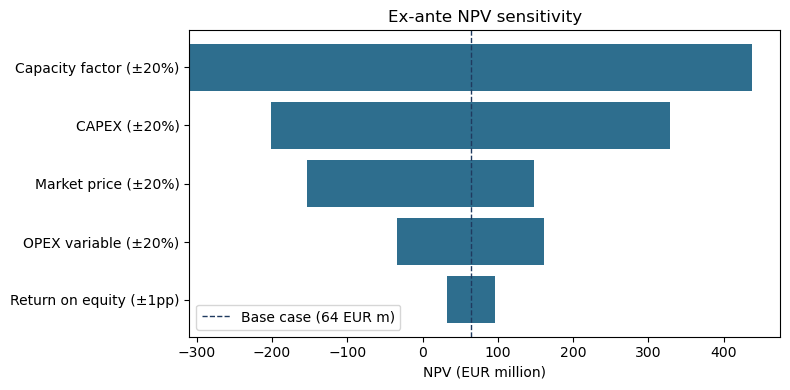

In [6]:
def npv_with_override(**overrides):
    a = assumptions.copy()
    a.update({k: v for k, v in overrides.items() if k not in ("capacity_factor", "capex_m")})
    a["wacc"] = wacc(a)
    prices = np.full(a["op_life"], a["exante_price"])
    return run_dcf(a, prices,
                    capex_m=overrides.get("capex_m"),
                    capacity_factor=overrides.get("capacity_factor"))["outputs"]["npv_m"]

base_npv = npv_with_override()

scenarios = {
    "Market price (\u00b120%)": dict(low=dict(exante_price=24), high=dict(exante_price=36)),
    "Capacity factor (\u00b120%)": dict(low=dict(capacity_factor=0.40), high=dict(capacity_factor=0.60)),
    "CAPEX (\u00b120%)": dict(low=dict(capex_m=1789), high=dict(capex_m=1193)),
    "Return on equity (\u00b11pp)": dict(low=dict(return_on_equity=0.09), high=dict(return_on_equity=0.11)),
    "OPEX variable (\u00b120%)": dict(low=dict(opex_var=11.51), high=dict(opex_var=7.67)),
}

rows = []
for label, sc in scenarios.items():
    low = npv_with_override(**sc["low"])
    high = npv_with_override(**sc["high"])
    rows.append((label, low, high))

tornado = pd.DataFrame(rows, columns=["scenario", "npv_low", "npv_high"]).set_index("scenario")
tornado["spread"] = (tornado["npv_high"] - tornado["npv_low"]).abs()
tornado = tornado.sort_values("spread")

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(tornado))
lo = tornado[["npv_low", "npv_high"]].min(axis=1)
hi = tornado[["npv_low", "npv_high"]].max(axis=1)
ax.barh(y, hi - lo, left=lo, color="#2E6E8E")
ax.axvline(base_npv, color="#1F3A5F", linestyle="--", linewidth=1, label=f"Base case ({base_npv:.0f} EUR m)")
ax.set_yticks(y); ax.set_yticklabels(tornado.index)
ax.set_xlabel("NPV (EUR million)")
ax.set_title("Ex-ante NPV sensitivity")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Monte Carlo simulation

Three inputs are drawn independently for each simulation and held constant across the full
25-year horizon: the long-run market price, the capacity factor, and the CAPEX outturn.

- **Price**: lognormal, mean EUR 30/MWh, standard deviation EUR 7.3/MWh matched to the
  volatility of NL day-ahead prices in 2015-2019, the information available at the time of the
  tender.
- **Capacity factor**: normal, mean 50%, standard deviation 3 percentage points typical
  uncertainty range for a P50 wind resource estimate at this stage.
- **CAPEX**: normal, mean EUR 1,491m, standard deviation EUR 150m informed by the spread
  between the EIB (2020) and CREG (2016) cost estimates.

Because of the SDE+ floor and cap, project value does not respond linearly to the price draw:
outcomes are compressed between the floor and the tender amount, and move freely only outside
that band.

In [7]:
N_SIMS = 20_000

price_std = 7.3
capex_std = 150
cf_std = 0.03

sigma = np.sqrt(np.log(1 + (price_std / assumptions["exante_price"]) ** 2))
mu = np.log(assumptions["exante_price"]) - sigma ** 2 / 2
price_draws = rng.lognormal(mu, sigma, N_SIMS)
capex_draws = rng.normal(assumptions["capex_eib_m"], capex_std, N_SIMS)
cf_draws = np.clip(rng.normal(assumptions["capacity_factor"], cf_std, N_SIMS), 0.30, 0.65)

npv_draws = np.empty(N_SIMS)
for i in range(N_SIMS):
    prices = np.full(assumptions["op_life"], price_draws[i])
    npv_draws[i] = run_dcf(assumptions, prices, capex_m=capex_draws[i], capacity_factor=cf_draws[i])["outputs"]["npv_m"]

print(f"Mean NPV:        {npv_draws.mean():,.1f} EUR m")
print(f"Median NPV:      {np.median(npv_draws):,.1f} EUR m")
print(f"5th percentile:  {np.percentile(npv_draws, 5):,.1f} EUR m")
print(f"95th percentile: {np.percentile(npv_draws, 95):,.1f} EUR m")
print(f"P(NPV < 0):      {(npv_draws < 0).mean():.1%}")


Mean NPV:        -0.4 EUR m
Median NPV:      8.1 EUR m
5th percentile:  -422.3 EUR m
95th percentile: 392.0 EUR m
P(NPV < 0):      48.6%


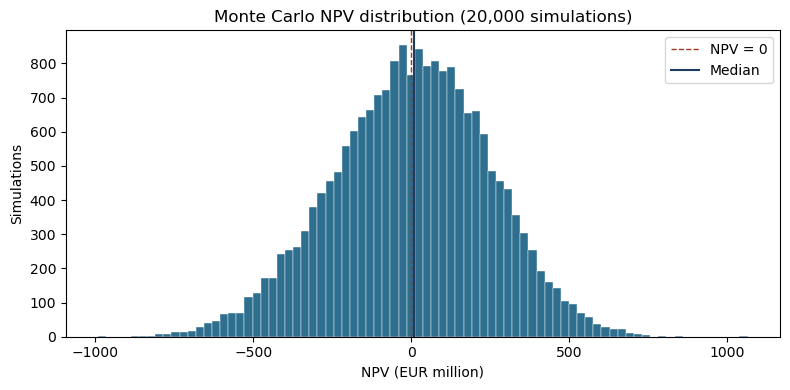

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(npv_draws, bins=80, color="#2E6E8E", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="#993C1D", linestyle="--", linewidth=1, label="NPV = 0")
ax.axvline(np.median(npv_draws), color="#1F3A5F", linestyle="-", linewidth=1.5, label="Median")
ax.set_xlabel("NPV (EUR million)")
ax.set_ylabel("Simulations")
ax.set_title(f"Monte Carlo NPV distribution ({N_SIMS:,} simulations)")
ax.legend()
plt.tight_layout()
plt.show()


Most of the downside comes from operational years 16-25, after the subsidy period ends: the
project is fully exposed to the market price in those years with no floor protection, so a
below-average price draw weighs on ten unprotected years rather than being cushioned throughout.

### Project value trajectories

Cumulative discounted cash flow over the project life for a sample of simulations, illustrating
how outcomes fan out as uncertainty compounds over time.

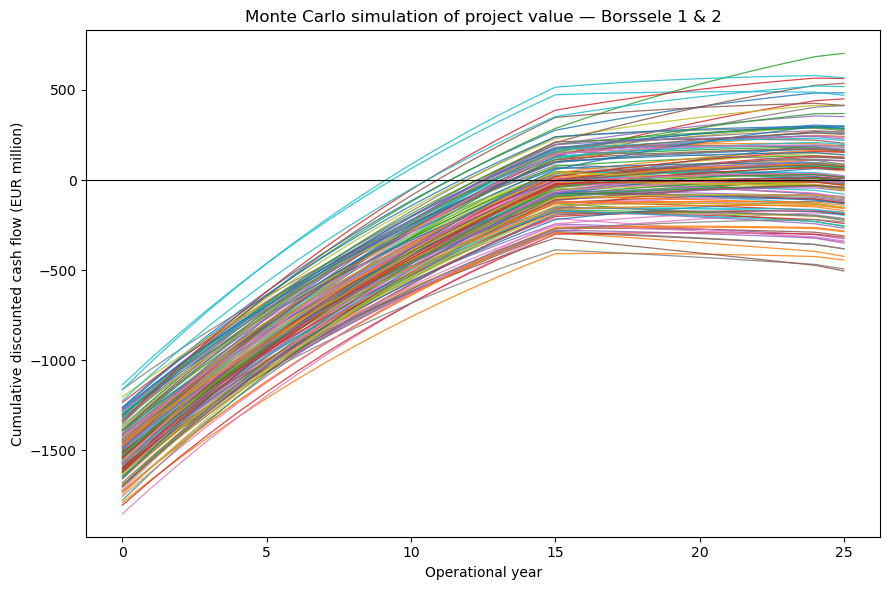

In [10]:
N_PATHS = 150
sample_idx = rng.choice(N_SIMS, N_PATHS, replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for i in sample_idx:
    prices = np.full(assumptions["op_life"], price_draws[i])
    path = run_dcf(assumptions, prices, capex_m=capex_draws[i], capacity_factor=cf_draws[i])["df"]
    ax.plot(path["year"], path["cum_dfcf"] / 1_000_000, linewidth=0.9, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Operational year")
ax.set_ylabel("Cumulative discounted cash flow (EUR million)")
ax.set_title("Monte Carlo simulation of project value \u2014 Borssele 1 & 2")
plt.tight_layout()
plt.savefig("borssele_montecarlo_fanchart.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Ex-post analysis

Realised NL wholesale day-ahead prices (2021 to mid-2026) replace the ex-ante assumption; years
beyond the available data use the post-actuals price assumption (EUR 80/MWh).

In [12]:
price_data = pd.read_csv("NL_wholesale_electricity_prices.csv")
price_data["Date"] = pd.to_datetime(price_data["Date"])
price_data["Year"] = price_data["Date"].dt.year
yearly_avg = price_data.groupby("Year")["Price (EUR/MWh)"].mean()

op_years = np.arange(1, assumptions["op_life"] + 1)
calendar_years = assumptions["cod"] - 1 + op_years
expost_prices = np.array([yearly_avg.get(cy, assumptions["post_price"]) for cy in calendar_years])

result_ep = run_dcf(assumptions, expost_prices)
o_ep = result_ep["outputs"]

print(f"Ex-ante NPV:  {o['npv_m']:,.1f} EUR m   |   IRR: {o['irr']:.2%}")
print(f"Ex-post NPV:  {o_ep['npv_m']:,.1f} EUR m   |   IRR: {o_ep['irr']:.2%}")


Ex-ante NPV:  63.6 EUR m   |   IRR: 4.91%
Ex-post NPV:  1,324.4 EUR m   |   IRR: 14.00%


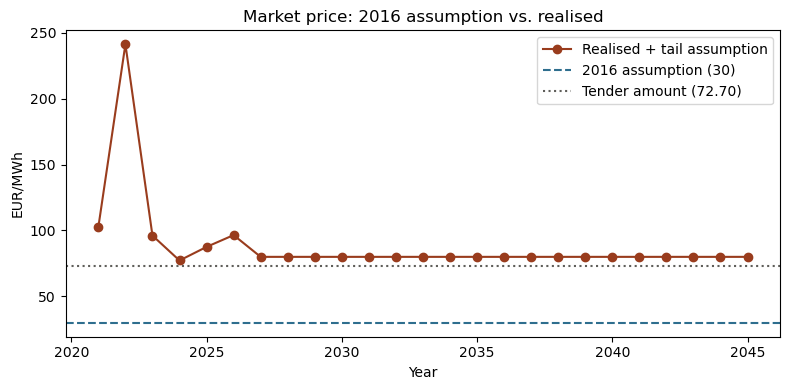

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(calendar_years, expost_prices, marker="o", color="#993C1D", label="Realised + tail assumption")
ax.axhline(assumptions["exante_price"], color="#2E6E8E", linestyle="--", label="2016 assumption (30)")
ax.axhline(assumptions["tender"], color="#5F5E5A", linestyle=":", label="Tender amount (72.70)")
ax.set_xlabel("Year"); ax.set_ylabel("EUR/MWh")
ax.set_title("Market price: 2016 assumption vs. realised")
ax.legend()
plt.tight_layout()
plt.show()


From 2021 onward, realised prices exceed the tender amount in most years, so the project
earns the full market price rather than the subsidised amount 2022 in particular accounts for
a large share of the total value gained relative to the 2016 expectation.

## 7. Benchmark: Norges Bank transaction

In April 2021, Norges Bank Investment Management paid EUR 1,375m for a 50% equity stake in
Borssele 1&2 with no additional debt, implying a total equity value of approximately EUR 2,750m.
The model's post-2021 cash flows are discounted to the same point in time and net of outstanding
project debt to produce a comparable equity value.

In [14]:
future_pv_t0 = result_ep["df"].loc[result_ep["df"]["year"] >= 1, "dfcf"].sum() / 1_000_000
ev_2021 = future_pv_t0 * (1 + assumptions["wacc"]) ** 1
debt_2021 = assumptions["debt_share"] * assumptions["capex_eib_m"]
equity_2021 = ev_2021 - debt_2021

print(f"Model equity value (2021):     {equity_2021:,.0f} EUR m")
print(f"Norges Bank implied equity:    2,750 EUR m")
print(f"Difference:                    {2750 - equity_2021:,.0f} EUR m")


Model equity value (2021):     1,893 EUR m
Norges Bank implied equity:    2,750 EUR m
Difference:                    857 EUR m


The model's equity value sits below the price Norges Bank paid consistent with core
infrastructure investors typically accepting a lower required return than the WACC used here, or
pricing in a more constructive long-term view of power prices at the time of the transaction.

## 8. CAPEX check: the 2016 bid under CREG's cost estimate

Re-running the ex-ante case with CREG's 2016 CAPEX estimate (EUR 1,891m) instead of the EIB
figure (EUR 1,491m) tests whether the winning bid still made sense under a more conservative,
outsider's view of construction costs.

In [15]:
result_creg = run_dcf(assumptions, exante_prices, capex_m=assumptions["capex_creg_m"])
print(f"Ex-ante NPV with EIB CAPEX (1,491):  {o['npv_m']:,.1f} EUR m")
print(f"Ex-ante NPV with CREG CAPEX (1,891): {result_creg['outputs']['npv_m']:,.1f} EUR m")


Ex-ante NPV with EIB CAPEX (1,491):  63.6 EUR m
Ex-ante NPV with CREG CAPEX (1,891): -291.4 EUR m


The bid only clears its cost of capital once construction costs are assumed below the CREG
estimate consistent with Ørsted's actual costs, per the EIB, coming in materially lower.